<a href="https://colab.research.google.com/github/JJsupercoder/GIS-Green-Area-Coverage/blob/main/ConvLSTM_Greenery_Prediction_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building the Conv LSTM Model

In [ ]:
import numpy as np
import torch

class ConvLSTMCell(torch.nn.Module):
    def __init__(self, input_size, hidden_size, kernel_size = (5, 5)):
        super(ConvLSTMCell, self).__init__()
        self.input_size = input_size #(channels, height, width)
        self.hidden_size = hidden_size #(channels, height, width)

        # Input gate parameters
        # Initialize Combined Conv Layer from ((Ic + Hc) * H * W) --> (4*Hc * H * W)
        self.combinedConv = torch.nn.Conv2d(
                                            in_channels = self.input_size[0] + self.hidden_size[0],
                                            out_channels= 4*self.hidden_size[0],
                                            kernel_size=kernel_size,
                                            padding = (kernel_size[0]//2, kernel_size[0]//2),
                                            bias = True)

        self.init_weights()

    def init_weights(self):
        for p in self.parameters():
            if p.data.ndimension() >= 2:
                torch.nn.init.xavier_uniform_(p.data)
            else:
                torch.nn.init.zeros_(p.data)

    def forward(self, xt, prev = None):
        if prev == None:
            ht_, ct_ = torch.zeros(self.hidden_size).unsqueeze(0), torch.zeros(self.hidden_size).unsqueeze(0)
        else:
            ht_, ct_ = prev
        xt = xt.reshape(self.input_size).unsqueeze(0)
        xh = torch.cat([xt, ht_], dim=1)
        comConv = self.combinedConv(xh)
        cc_i, cc_f, cc_o, cc_g = torch.split(comConv, self.hidden_size[0], dim=1)
        it = torch.sigmoid(cc_i)
        ft = torch.sigmoid(cc_f)
        ot = torch.sigmoid(cc_o)
        # gt = torch.tanh(cc_g)
        gt = torch.nn.functional.celu(cc_g)

        # Update hidden state
        ct = ft * ct_ + it * gt
        ht = ot * torch.tanh(ct)
        return ht, ct

class convLSTM(torch.nn.Module):
    def __init__(self, inputDims, outputDims, num_layers = 2, lookback= 5, kernel_size = 3, lr = 0.001):
        # Dims are in form (channels, width, height)
        super().__init__()
        self.inputDims = inputDims
        self.outputDims = outputDims
        self.lookback = lookback
        self.layers = torch.nn.ModuleList()
        self.lr = lr
        for layer in range(num_layers-2):
            self.layers.append(ConvLSTMCell(inputDims, inputDims, kernel_size = kernel_size))
        self.layers.append(ConvLSTMCell(inputDims, outputDims, kernel_size = kernel_size))
        self.layers.append(ConvLSTMCell(outputDims, outputDims, kernel_size = kernel_size))


    def forward(self, input, return_history = False):
        history = [[0 for i in range(self.lookback)] for layer in range(len(self.layers))] #history[layer][step]
        history[0][0] = self.layers[0](input[0], None) #input to layer 0 at step 0, ht_ and ct_ = none --> ht and ct of layer 0 at step 0
        for step in range(1, self.lookback):
            history[0][step] = self.layers[0](input[step], history[0][step-1]) #input to layer 0 at step = step, ht and ct of layer 0 at step = step
        for layer in range(1, len(self.layers)):
            history[layer][0] = self.layers[layer](history[layer-1][0][0], None) #ht of  layer i-1 at step = 0, ht_ and ct_ = none
            for step in range(1, self.lookback):
                history[layer][step] = self.layers[layer](history[layer-1][step][0], history[layer][step-1]) #ht of  layer i-1 at step = step, ht and ct of layer i at step-1

        if not return_history:
            return history[-1][-1]
        return (history[-1][-1], history)

    def predict(self, inputs):
        assert len(inputs) == self.lookback, f"Input Sequence should be of length {self.lookback}"
        return self.forward(self, inputs)

    def customLoss(self, pred, target, predIndex):
        return torch.nn.functional.l1_loss(pred/(torch.max(pred)+0.00000000001), target/(torch.max(target)+0.00000000001), reduction = 'sum') \
        + 0.5*torch.abs(torch.tensor(self.fclLookup(predIndex)) / self.calc_percent_greenery_by_fixed_coord(pred.detach().numpy().reshape(18, 23)) + self.calc_percent_greenery_by_fixed_coord(pred.detach().numpy().reshape(18, 23))/torch.tensor(self.fclLookup(predIndex)) - 2) \
        + 0.5*(torch.abs((pred[0, 0, 10, 11]- target[0, 0, 10, 11])/target[0, 0, 10, 11]))

    def calc_percent_greenery_by_fixed_coord(self, ndvi_mat, min_ndvi_coord = (10,11)):
        min_ndvi = ndvi_mat[min_ndvi_coord[0], min_ndvi_coord[1]]
        max_ndvi = np.max(ndvi_mat)
        count = 0
        for i in range(len(ndvi_mat)):
            for j in range(len(ndvi_mat[i])):
                if min_ndvi <= ndvi_mat[i, j] <= max_ndvi:
                    count += 1

        total = len(ndvi_mat) * len(ndvi_mat[0])
        percent = count / total
        return percent

    def fclLookup(self, predIndex):
        # return calculated values of FCL from the excel data sheet
        return [39.13043,
        33.33333333,
        22.9468599,
        10.38647343,
        24.87922705,
        26.8115942,
        8.45410628,
        15.70048309,
        12.80193237,
        14.73429952,
        9.178743961,
        16.90821256,
        20.04830918,
        12.07729469,
        25.36231884,
        11.352657,
        11.5942029,
        5.314009662,
        8.937198068,
        7.729468599,
        14.25120773,
        2.657004831,
        3.623188406,
        2.898550725,
        2.415458937,
        2.657004831,
        2.898550725,
        2.173913043,
        1.207729469,
        1.207729469,
        0.9661835749][predIndex]/100

    def train(self, dataset, epochs):

        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
        meanLoss = 0
        for epoch in range(epochs):
            loss = torch.tensor(0.0)
            predIndex = np.random.randint(self.lookback, len(dataset)-1)
            train = dataset[predIndex - self.lookback: predIndex]
            target = dataset[predIndex].unsqueeze(0)
            prediction = self(train)
            loss += self.customLoss(prediction[0], target, predIndex)

            meanLoss += loss
            loss.backward()
            optimizer.step()
            self.zero_grad()
            if (epoch+1) % 100 == 0:
                print(f"Epoch {epoch+1}: {meanLoss/100}")
                meanLoss = 0


# Loading the NDVI calculated maps

In [ ]:
import numpy as np
tr = np.load('train_ndvi.npy')
tt = np.load('test_ndvi.npy')
data = np.concatenate((tr, tt))
print(data.shape)
tr1 = data[:-6]
tt1 = data[-6:]
print(tr1.shape)
print(tt1.shape)
np.save('train_ndvi.npy', tr1)
np.save('test_ndvi.npy', tt1)
# np.save('ndvi_maps_updated.npy', data)

(31, 1, 18, 23)
(25, 1, 18, 23)
(6, 1, 18, 23)


#Training the LSTM model supporting 2D map data

In [ ]:
import torch, numpy as np

class mapLSTM():
    def __init__(self, dims = (18, 23), lookback = 4, layers = 2, lr = 0.001, dropout = 0.0):
        self.dims = dims
        self.lookback = lookback
        self.lr = lr
        self.model = torch.nn.LSTM(dims[0]*dims[1], dims[0]*dims[1], num_layers = layers, dropout = dropout)
        self.optimizer= torch.optim.Adam(self.model.parameters(), lr=self.lr)

    def forward(self, map_seq):
        input = torch.tensor(map_seq).reshape(-1, self.dims[0]*self.dims[1])
        output = self.model(torch.tensor(map_seq).reshape(-1, self.dims[0]*self.dims[1]))[0][-1]
        return output.reshape(self.dims[0], self.dims[1])

    def train(self, data, epochs = 2000):
        dataTensor = torch.tensor(data)
        meanLoss = torch.tensor(0.)
        for epoch in range(epochs):
            if np.random.random() < 0.4:
                index = len(data) - self.lookback - 1
            else:
                index = np.random.randint(len(data) - self.lookback)
            target = dataTensor[index + self.lookback].reshape(self.dims[0]*self.dims[1])
            pred = self.model((dataTensor[index:index + self.lookback].reshape(-1, self.dims[0]*self.dims[1])))[0][-1]
            loss = torch.nn.functional.l1_loss(pred, target, reduction = 'sum')
            meanLoss += loss
            loss.backward()
            self.optimizer.step()
            self.optimizer.zero_grad()
            if (epoch + 1) % 100 == 0:
                print(f'Epoch {epoch + 1} : {meanLoss.item()/100}')
                meanLoss = torch.tensor(0.)




In [ ]:

# data = np.load('ndvi_maps_updated.npy').astype(np.float32)
# np.save( 'train_ndvi.npy', data[:24])
dataTrain = np.load('train_ndvi.npy')
# np.save( 'test_ndvi.npy', data[24:])
dataTest = np.load('test_ndvi.npy')


lstm = mapLSTM(lookback = 4, lr = 0.001, layers = 3)
lstm.train(dataTrain, 3000)


Epoch 100 : 10.96988525390625
Epoch 200 : 8.854700317382813
Epoch 300 : 7.399873046875
Epoch 400 : 6.562060546875
Epoch 500 : 7.06515380859375
Epoch 600 : 6.65907470703125
Epoch 700 : 5.930546875
Epoch 800 : 6.048287963867187
Epoch 900 : 4.93271484375
Epoch 1000 : 5.027591247558593
Epoch 1100 : 4.612891540527344
Epoch 1200 : 5.3876495361328125
Epoch 1300 : 5.514251708984375
Epoch 1400 : 4.519922485351563
Epoch 1500 : 5.226439208984375
Epoch 1600 : 4.638506774902344
Epoch 1700 : 4.624037170410157
Epoch 1800 : 4.314943237304687
Epoch 1900 : 3.561845397949219
Epoch 2000 : 3.7265380859375
Epoch 2100 : 3.314686584472656
Epoch 2200 : 3.043946533203125
Epoch 2300 : 2.737198791503906
Epoch 2400 : 2.93787353515625
Epoch 2500 : 2.774617919921875
Epoch 2600 : 2.705096435546875
Epoch 2700 : 2.8226617431640624
Epoch 2800 : 2.4458612060546874
Epoch 2900 : 2.2982647705078123
Epoch 3000 : 2.3999168395996096


In [ ]:
print(dataTrain.shape)
print(dataTest.shape)

(25, 1, 18, 23)
(6, 1, 18, 23)


# Predicting greenery using model

4
(25, 1, 18, 23)


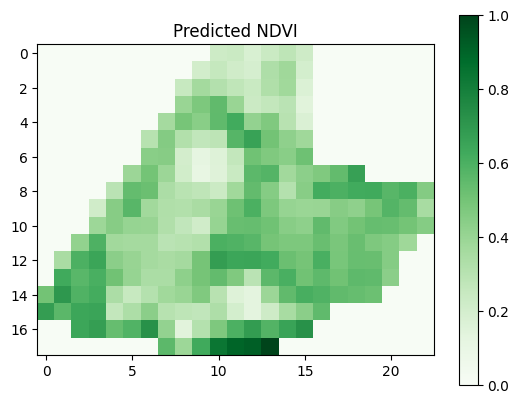

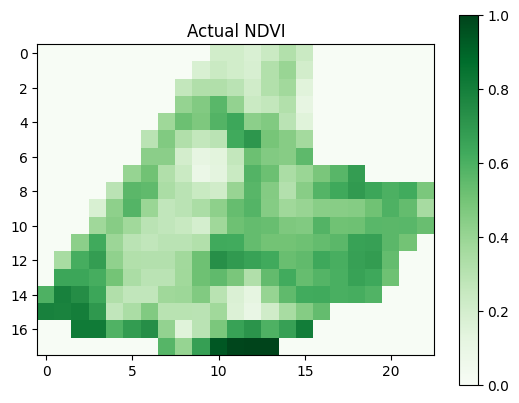

Step: 4
Predicted NDVI Greenery Percentage: 18.115942028985508 Actual NDVI  Greenery Percentage: 24.879227053140095


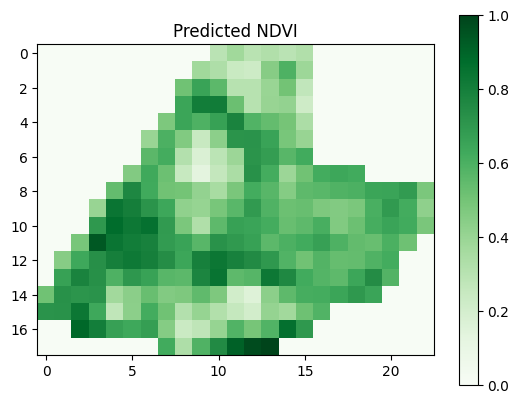

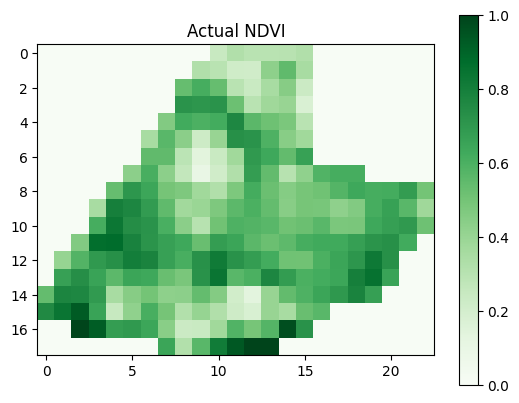

Step: 5
Predicted NDVI Greenery Percentage: 16.183574879227052 Actual NDVI  Greenery Percentage: 26.811594202898554


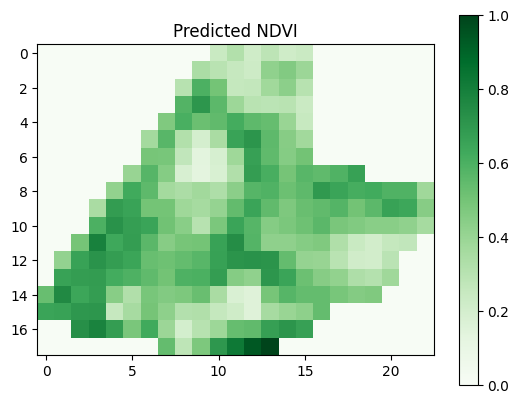

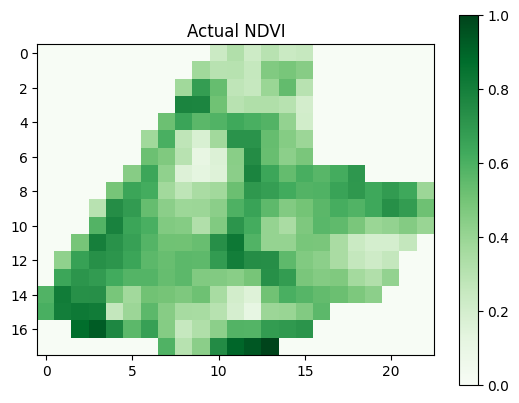

Step: 6
Predicted NDVI Greenery Percentage: 10.628019323671497 Actual NDVI  Greenery Percentage: 8.454106280193237


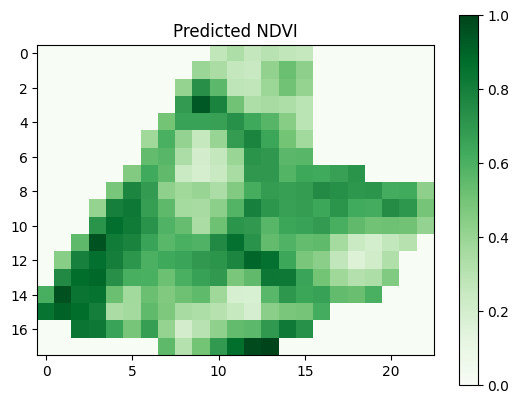

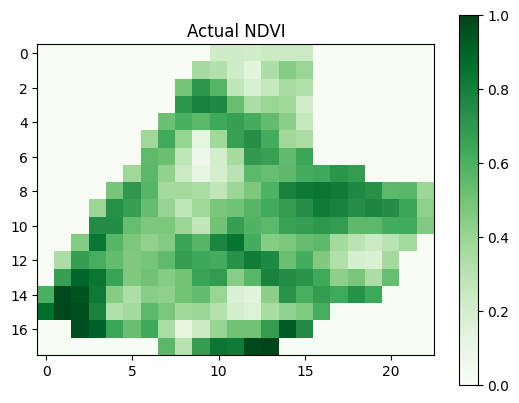

Step: 7
Predicted NDVI Greenery Percentage: 13.043478260869565 Actual NDVI  Greenery Percentage: 15.70048309178744


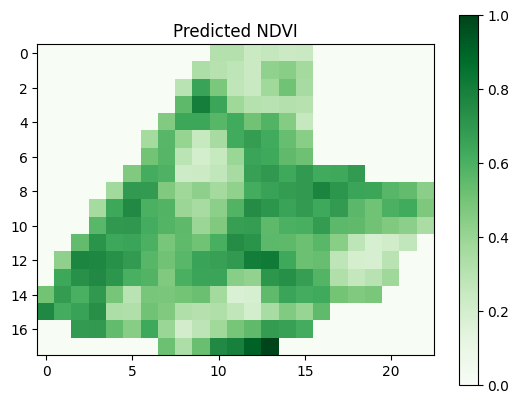

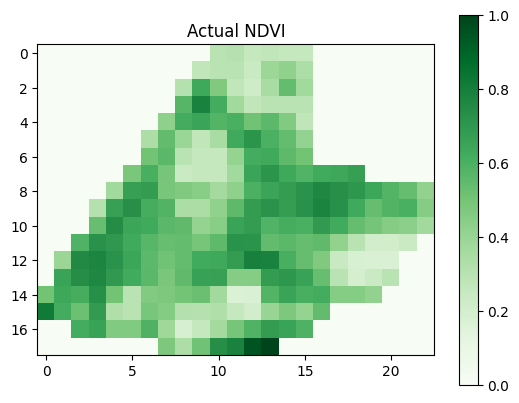

Step: 8
Predicted NDVI Greenery Percentage: 11.594202898550725 Actual NDVI  Greenery Percentage: 12.80193236714976


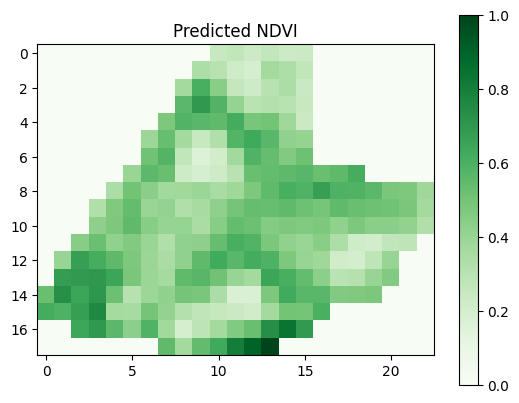

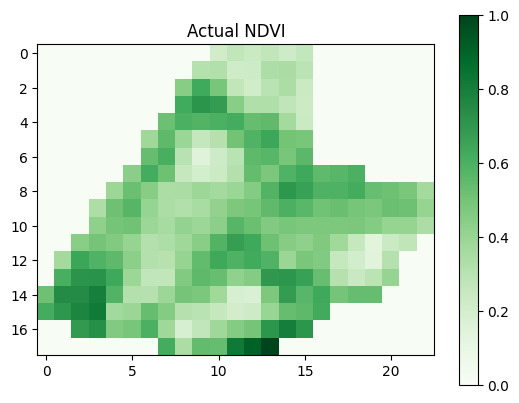

Step: 9
Predicted NDVI Greenery Percentage: 17.874396135265698 Actual NDVI  Greenery Percentage: 14.734299516908212


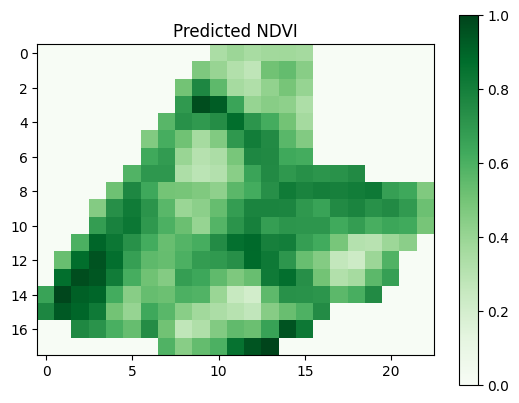

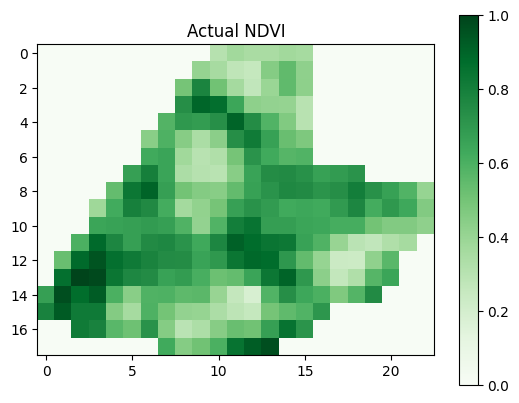

Step: 10
Predicted NDVI Greenery Percentage: 18.115942028985508 Actual NDVI  Greenery Percentage: 9.178743961352657


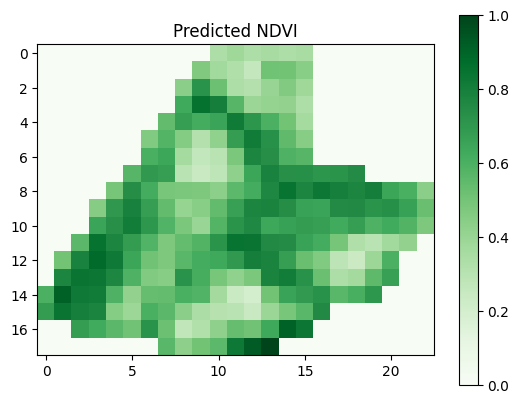

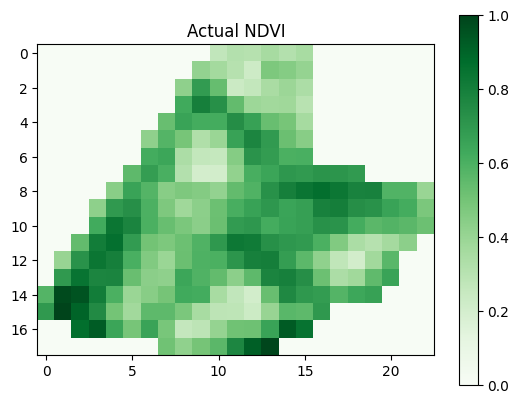

Step: 11
Predicted NDVI Greenery Percentage: 15.458937198067632 Actual NDVI  Greenery Percentage: 16.908212560386474


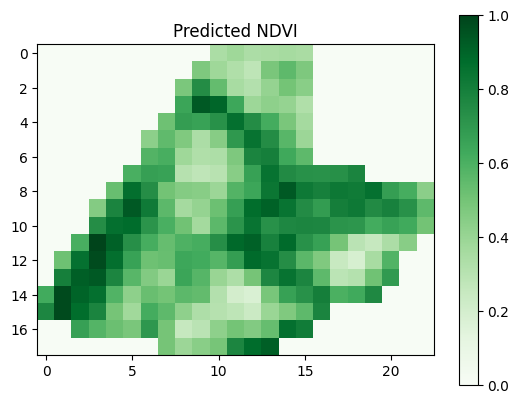

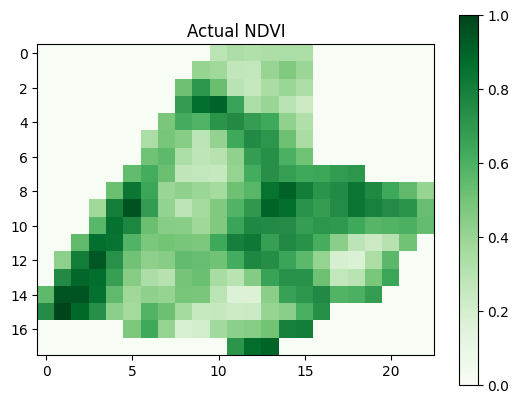

Step: 12
Predicted NDVI Greenery Percentage: 20.28985507246377 Actual NDVI  Greenery Percentage: 20.048309178743963


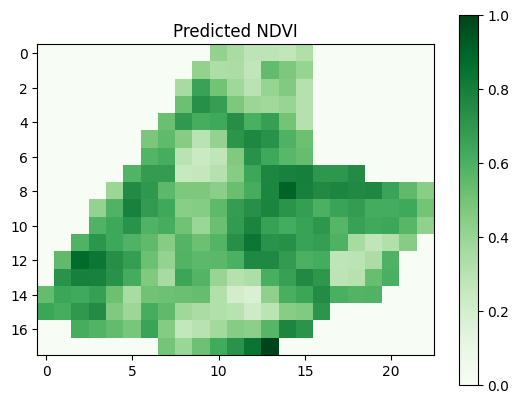

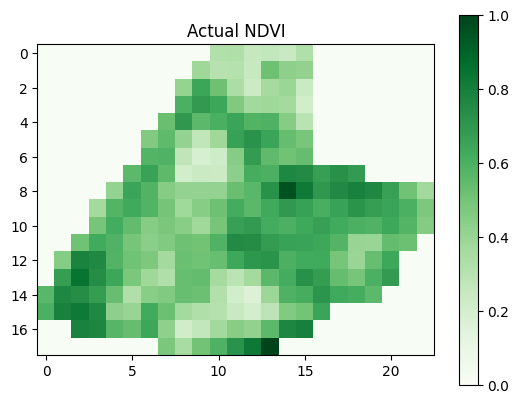

Step: 13
Predicted NDVI Greenery Percentage: 13.768115942028986 Actual NDVI  Greenery Percentage: 12.077294685990339


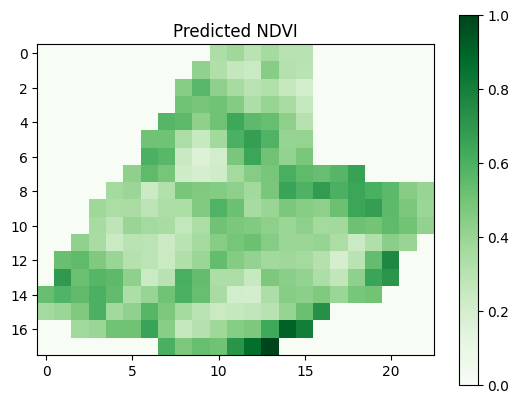

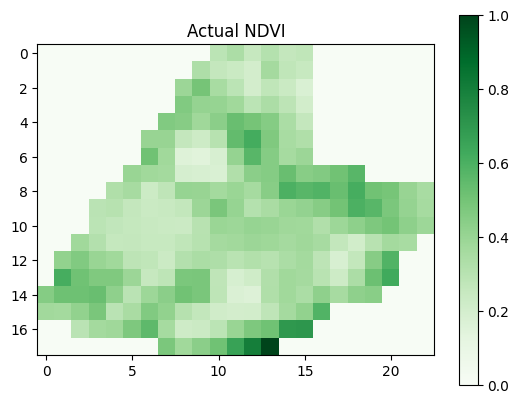

Step: 14
Predicted NDVI Greenery Percentage: 22.463768115942027 Actual NDVI  Greenery Percentage: 25.36231884057971


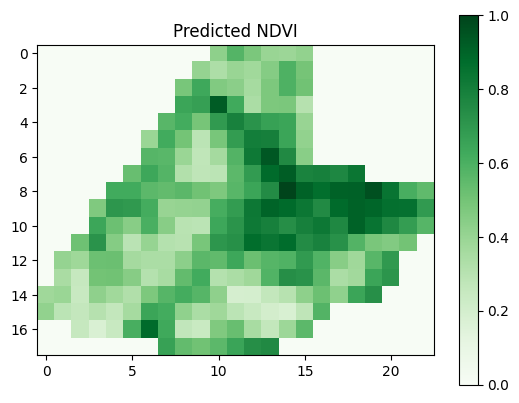

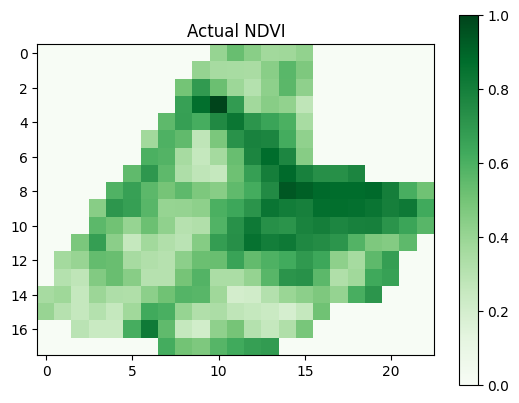

Step: 15
Predicted NDVI Greenery Percentage: 13.526570048309178 Actual NDVI  Greenery Percentage: 11.352657004830919


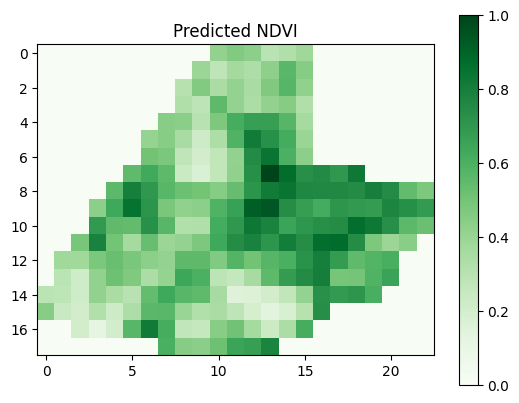

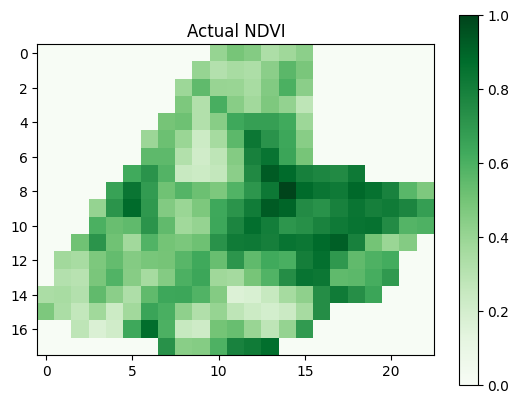

Step: 16
Predicted NDVI Greenery Percentage: 13.526570048309178 Actual NDVI  Greenery Percentage: 11.594202898550725


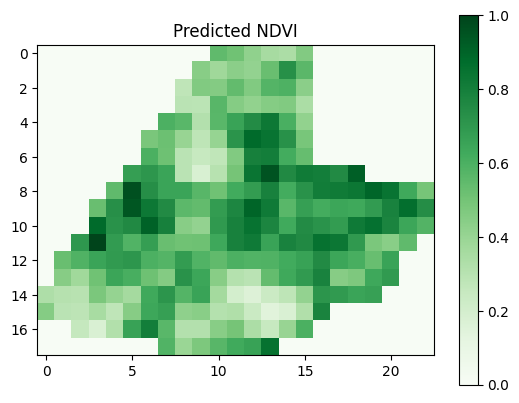

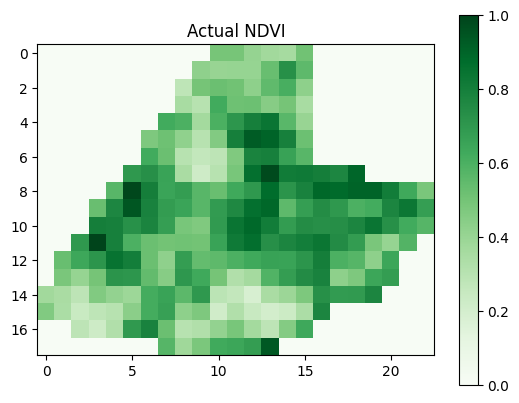

Step: 17
Predicted NDVI Greenery Percentage: 8.212560386473431 Actual NDVI  Greenery Percentage: 5.314009661835748


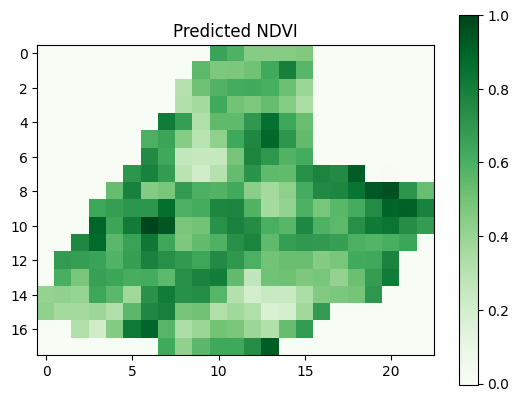

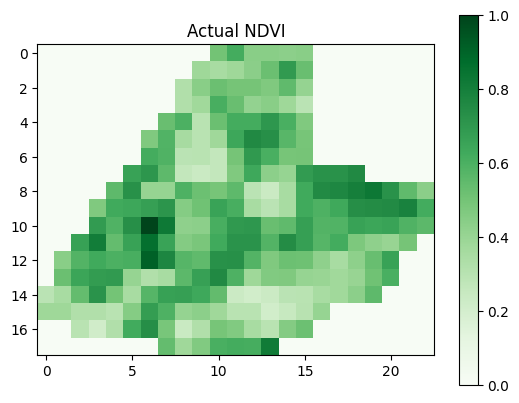

Step: 18
Predicted NDVI Greenery Percentage: 7.004830917874397 Actual NDVI  Greenery Percentage: 8.937198067632849


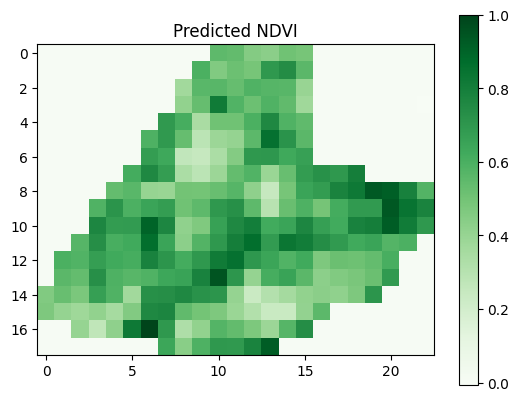

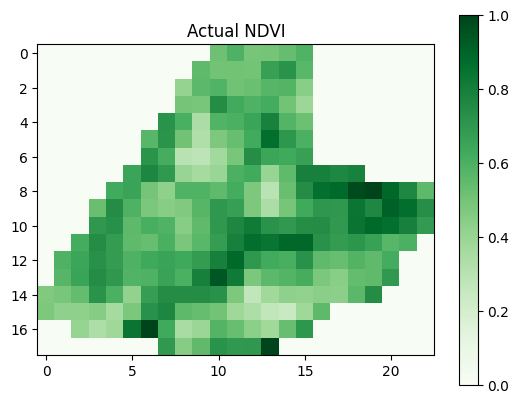

Step: 19
Predicted NDVI Greenery Percentage: 8.695652173913043 Actual NDVI  Greenery Percentage: 7.729468599033816


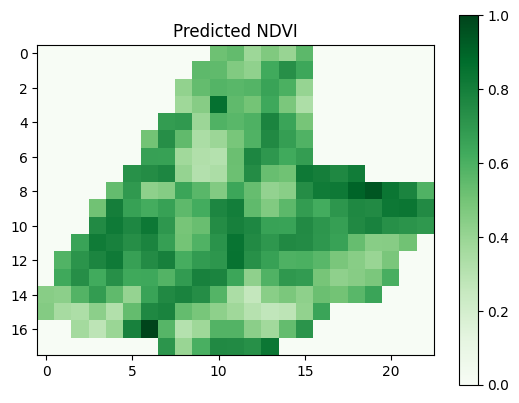

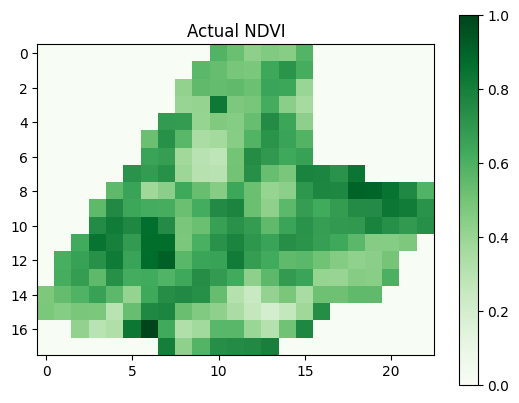

Step: 20
Predicted NDVI Greenery Percentage: 5.314009661835748 Actual NDVI  Greenery Percentage: 14.251207729468598


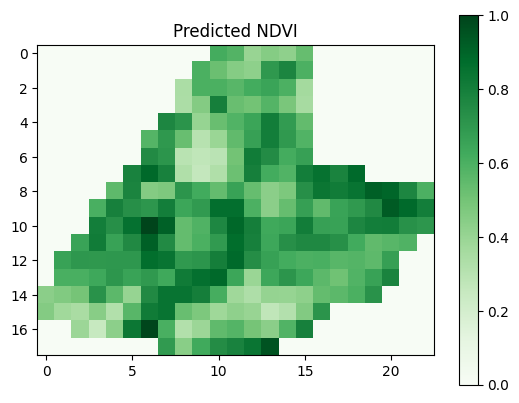

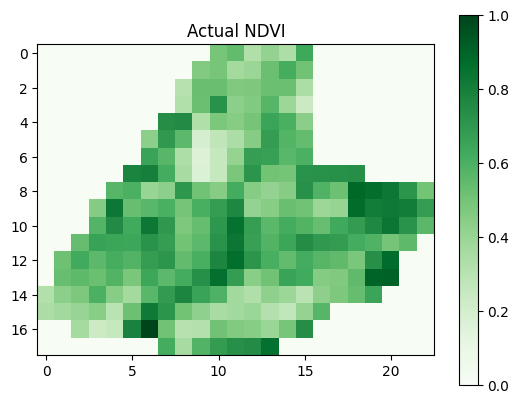

Step: 21
Predicted NDVI Greenery Percentage: 2.1739130434782608 Actual NDVI  Greenery Percentage: 2.657004830917874


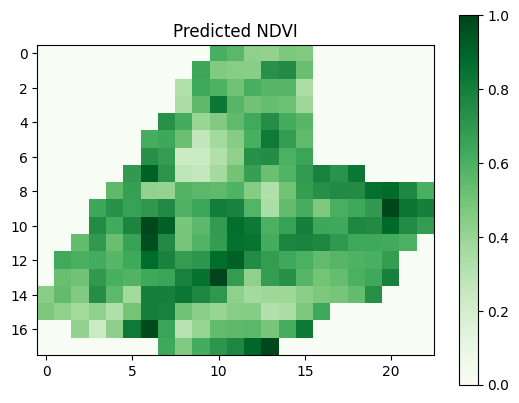

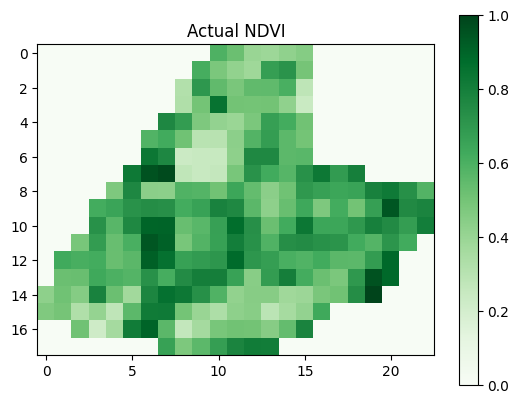

Step: 22
Predicted NDVI Greenery Percentage: 3.6231884057971016 Actual NDVI  Greenery Percentage: 3.6231884057971016


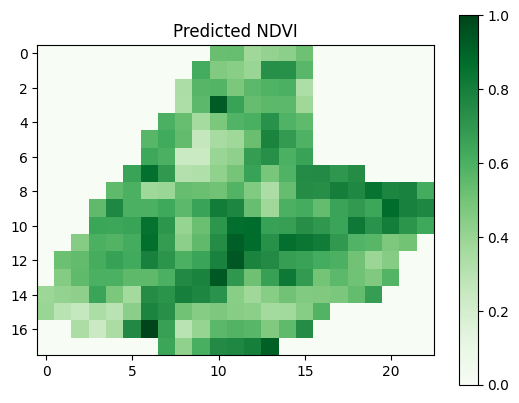

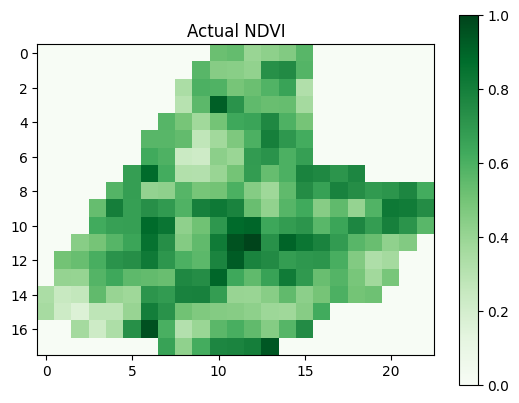

Step: 23
Predicted NDVI Greenery Percentage: 2.657004830917874 Actual NDVI  Greenery Percentage: 2.898550724637681


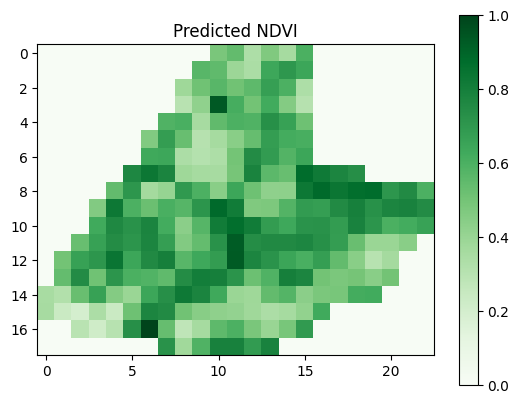

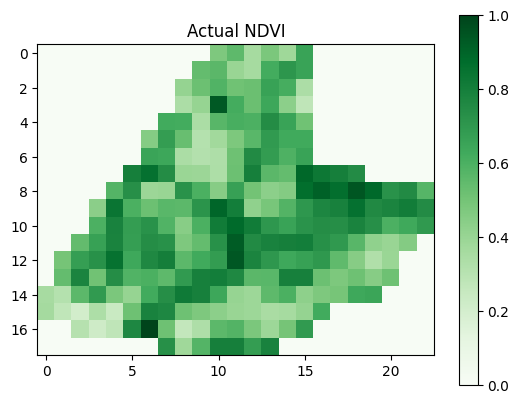

Step: 24
Predicted NDVI Greenery Percentage: 2.1739130434782608 Actual NDVI  Greenery Percentage: 2.4154589371980677


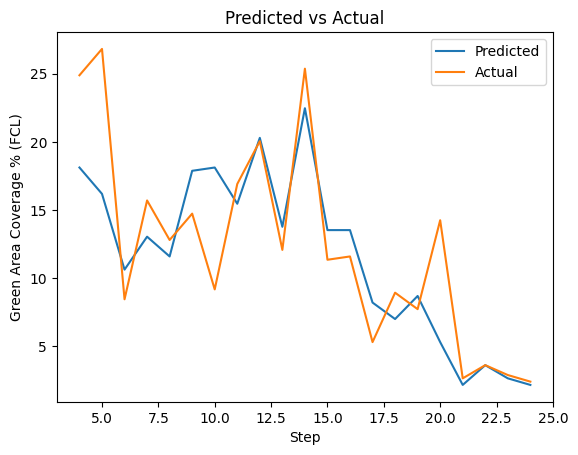

4
(6, 1, 18, 23)


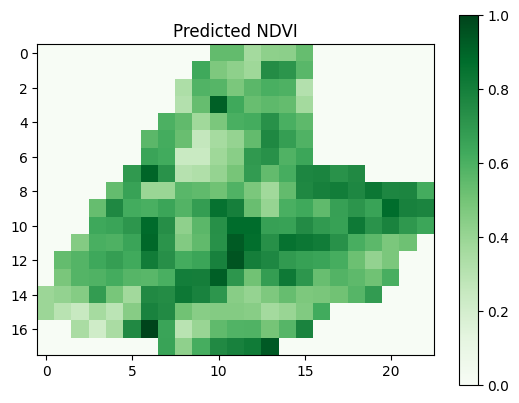

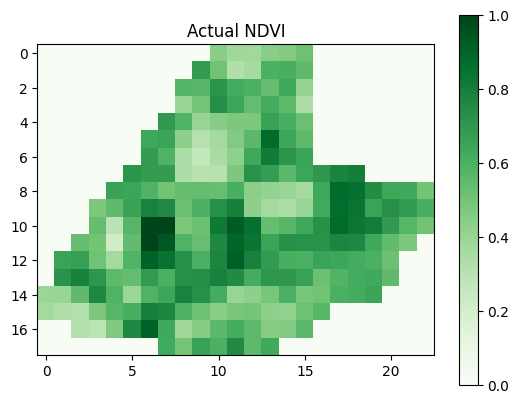

Step: 4
Predicted NDVI Greenery Percentage: 2.657004830917874 Actual NDVI  Greenery Percentage: 1.2077294685990339


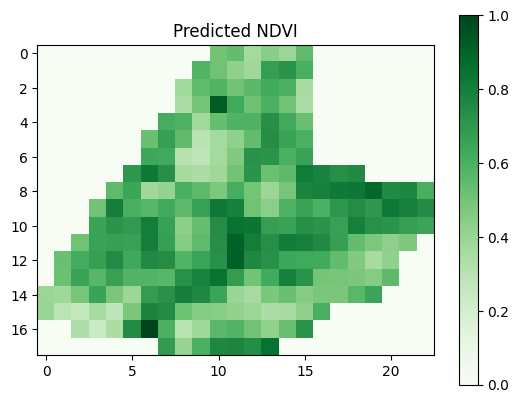

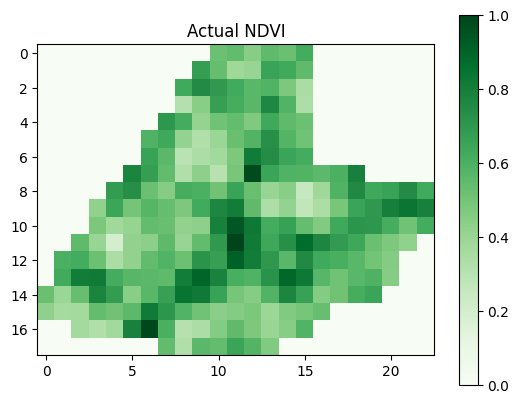

Step: 5
Predicted NDVI Greenery Percentage: 1.6908212560386473 Actual NDVI  Greenery Percentage: 0.966183574879227


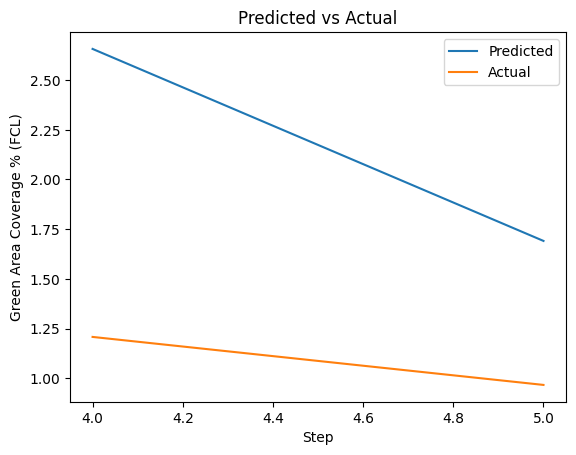

In [ ]:
from matplotlib import pyplot as plt

def calc_percent_greenery_by_fixed_coord(ndvi_mat, min_ndvi_coord = (10,11)):
    min_ndvi = ndvi_mat[min_ndvi_coord[0], min_ndvi_coord[1]]
    max_ndvi = np.max(ndvi_mat)
    count = 0
    for i in range(len(ndvi_mat)):
        for j in range(len(ndvi_mat[i])):
            if min_ndvi <= ndvi_mat[i, j] <= max_ndvi:
                count += 1

    total = len(ndvi_mat) * len(ndvi_mat[0])
    percent = count / total * 100
    return percent

def show_bw_image(img_gray, title=''):
    #show the grayscale image
    img_gray = img_gray/np.max(img_gray)
    plt.imshow(img_gray, cmap=plt.get_cmap('Greens'))
    plt.title(title)
    plt.colorbar()
    plt.show()


def plotData(data):
    pList = []
    aList = []
    steps = []
    print(lstm.lookback)
    print(data.shape)
    for s in range(lstm.lookback, len(data)):
        p = calc_percent_greenery_by_fixed_coord(lstm.forward(data[s - lstm.lookback: s]).detach().numpy().reshape(18, 23))
        a = calc_percent_greenery_by_fixed_coord(data[s].reshape(18,23))
        show_bw_image(lstm.forward(data[s - lstm.lookback: s]).detach().numpy().reshape(18, 23), "Predicted NDVI")
        show_bw_image(data[s].reshape(18,23), "Actual NDVI")
        print(f"Step: {s}")
        print(f"Predicted NDVI Greenery Percentage: {p} Actual NDVI  Greenery Percentage: {a}")
        pList.append(p)
        aList.append(a)
        steps.append(s)

    plt.plot(steps, pList, label = "Predicted")
    plt.plot(steps, aList, label = 'Actual')
    plt.xlabel("Step")
    plt.ylabel("Green Area Coverage % (FCL)")
    plt.title('Predicted vs Actual')
    plt.legend()
    plt.show()

plotData(dataTrain)
plotData(dataTest)

#Saving and loading the trained model for inference

In [ ]:
import pickle

# Save the model
filename = 'trained_lstm_model.pkl'
pickle.dump(lstm, open(filename, 'wb'))

# Load the model
loaded_model = pickle.load(open(filename, 'rb'))